# Notebook 2: Feature Engineering
**Project:** Where Do Fitness Businesses Thrive in Utah?

Takes the raw merged dataset from `01_data_collection.ipynb` and produces a clean, model-ready feature matrix.

**Features produced:**
- Business attributes: category (grouped), price tier, has_hours
- Location: competition density (1/3/5 km), market gap, city
- Demographics: income, education, age breakdown, home value
- Derived: income-to-competition ratio, gym density per capita

**Outputs:**
- `data/features_classifier.csv` — for predicting `is_thriving` (binary)
- `data/features_regressor.csv` — for predicting `success_score` (continuous, open businesses only)

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/utah_fitness_v2.csv', dtype={'zip_code': str})
print('Loaded:', df.shape)
print('Closed:', df['is_closed'].sum(), '| Open:', (df['is_closed'] == 0).sum())
df.head(3)

Loaded: (1081, 29)
Closed: 0 | Open: 1081


,id,name,zip_code,city,latitude,longitude,rating,review_count,category,distance,...,pct_bachelors,pct_prime_gym_age,competition_1km,competition_3km,competition_5km,is_thriving,log_review_count,success_score,gyms_in_zip,market_gap
0,g5_H-U7ek51C1tT1ep4igQ,Alpine Fitness,84004,Alpine,40.448977,-111.779317,4.3,16,gyms,NaN,...,21.770404,12.793709,4,11,15,1.0,2.833213,0.691987,5,22233.333333
1,HKOIqLtg9f780JHOouonGg,Alpine Physical Therapy,84004,Alpine,40.450027,-111.777381,5.0,6,physicaltherapy,NaN,...,21.770404,12.793709,4,11,15,NaN,1.945910,0.679938,5,22233.333333
2,aUVAXipfJjqpWOWANaEREA,Lifted Life Yoga Center,84004,Alpine,40.449110,-111.779050,4.9,7,yoga,NaN,...,21.770404,12.793709,4,11,15,NaN,2.079442,0.682286,5,22233.333333


## 1. Category Grouping

The raw Yelp category aliases are very granular (87+ unique values). We group them into
6 meaningful business types for modeling.

In [2]:
category_map = {
    # General gyms
    'gyms': 'general_gym',
    'intervaltraininggyms': 'general_gym',
    'bootcamps': 'general_gym',
    'crossfit': 'general_gym',

    # Mind-body / boutique
    'yoga': 'mind_body',
    'pilates': 'mind_body',
    'cycling': 'mind_body',
    'barre': 'mind_body',

    # Martial arts
    'martialarts': 'martial_arts',
    'karate': 'martial_arts',
    'taekwondo': 'martial_arts',
    'bjj': 'martial_arts',
    'brazilianjiujitsu': 'martial_arts',
    'selfdefenseclasses': 'martial_arts',
    'boxing': 'martial_arts',
    'muaythai': 'martial_arts',
    'kickboxing': 'martial_arts',

    # Personal / specialty training
    'healthtrainers': 'personal_training',
    'personaltrainers': 'personal_training',
    'weightlosscenters': 'personal_training',
    'nutritionists': 'personal_training',

    # Climbing / outdoor
    'rock_climbing': 'climbing_outdoor',
    'climbinggym': 'climbing_outdoor',
}

df['category_group'] = df['category'].map(category_map).fillna('other')

print('Category group distribution:')
print(df['category_group'].value_counts())

Category group distribution:
category_group
general_gym          293
martial_arts         217
mind_body            203
personal_training    190
other                174
climbing_outdoor       4
Name: count, dtype: int64


## 2. Derived Features

In [3]:
# Gym density per 1,000 residents in the zip
df['gym_density_per_1k'] = (df['gyms_in_zip'] / df['total_pop']) * 1000

# Income-to-competition ratio: higher = wealthy area with fewer gyms
df['income_per_competitor'] = df['median_income'] / (df['competition_3km'] + 1)

# Population potential per competitor within 3km
df['pop_per_competitor'] = df['total_pop'] / (df['competition_3km'] + 1)

# Engagement proxy: reviews per unit distance (closer businesses likely see more foot traffic)
# Only meaningful for open businesses
df['reviews_per_km'] = df['review_count'] / (df['distance'] / 1000 + 0.1)

print('Derived features added.')
df[[
    'name', 'gym_density_per_1k', 'income_per_competitor',
    'pop_per_competitor', 'reviews_per_km'
]].head(10)

Derived features added.


,name,gym_density_per_1k,income_per_competitor,pop_per_competitor,reviews_per_km
0,Alpine Fitness,0.479524,14208.333333,868.916667,NaN
1,Alpine Physical Therapy,0.479524,14208.333333,868.916667,NaN
2,Lifted Life Yoga Center,0.479524,14208.333333,868.916667,NaN
3,Paul Tom's Academy Of Mixed Martial Arts,0.330838,6685.000000,3190.555556,NaN
4,XD Fit,0.292807,5560.473684,2516.473684,NaN
5,"HOTWORX - Highland, UT - Alpine",0.330838,8595.000000,4102.142857,NaN
6,Mountain West Pilates,0.292807,6214.647059,2812.529412,NaN
7,Momentum Indoor Climbing- Lehi,0.248897,9988.615385,6799.230769,NaN
8,CrossFit Lehi,0.248897,9988.615385,6799.230769,NaN
9,Legends Boxing - Lehi,0.248897,9275.142857,6313.571429,NaN


## 4. Build Model-Ready Feature Matrices

### Feature set for both tasks:
| Feature | Type | Rationale |
|---|---|---|
| `category_group` | Categorical | Business type |
| `price` | Numeric | Price tier (0=unknown, 1–4) |
| `years_on_yelp` | Numeric | Longevity proxy via Wayback Machine first snapshot |
| `median_income` | Numeric | Neighborhood wealth |
| `median_home_value` | Numeric | Alternate wealth proxy |
| `median_age` | Numeric | Neighborhood age profile |
| `pct_bachelors` | Numeric | Education level |
| `pct_prime_gym_age` | Numeric | % pop 20–44 |
| `total_pop` | Numeric | Market size |
| `competition_1km` | Numeric | Hyper-local competition |
| `competition_3km` | Numeric | Neighborhood competition |
| `market_gap` | Numeric | Opportunity score |
| `gym_density_per_1k` | Numeric | Market saturation |
| `income_per_competitor` | Numeric | Spending power per competitor |

> **Note:** `rating` and `review_count` are NOT included as features — they are outputs of success, not inputs to it. We want to predict from *location and market conditions* only.
>
> `has_hours` was dropped — `years_on_yelp` (Wayback Machine) is a cleaner, more causally defensible longevity signal.

In [4]:
FEATURES = [
    # Business
    'category_group', 'price',
    # Neighborhood demographics
    'median_income', 'median_home_value', 'median_age',
    'pct_bachelors', 'pct_prime_gym_age', 'total_pop',
    # Competition / market
    'competition_1km', 'competition_3km',
    'market_gap', 'gym_density_per_1k', 'income_per_competitor',
]

# ── Classifier dataset ─────────────────────────────────────────────────────────
clf_df = df.dropna(subset=['is_thriving'])[FEATURES + ['is_thriving', 'id', 'name', 'zip_code', 'latitude', 'longitude']].copy()
clf_df = clf_df.dropna(subset=FEATURES)

print(f'Classifier dataset: {len(clf_df)} rows')
print('is_thriving distribution:')
print(clf_df['is_thriving'].value_counts())

clf_df.to_csv('data/features_classifier.csv', index=False)
print('Saved data/features_classifier.csv')

Classifier dataset: 164 rows
is_thriving distribution:
is_thriving
1.0    101
0.0     63
Name: count, dtype: int64
Saved data/features_classifier.csv


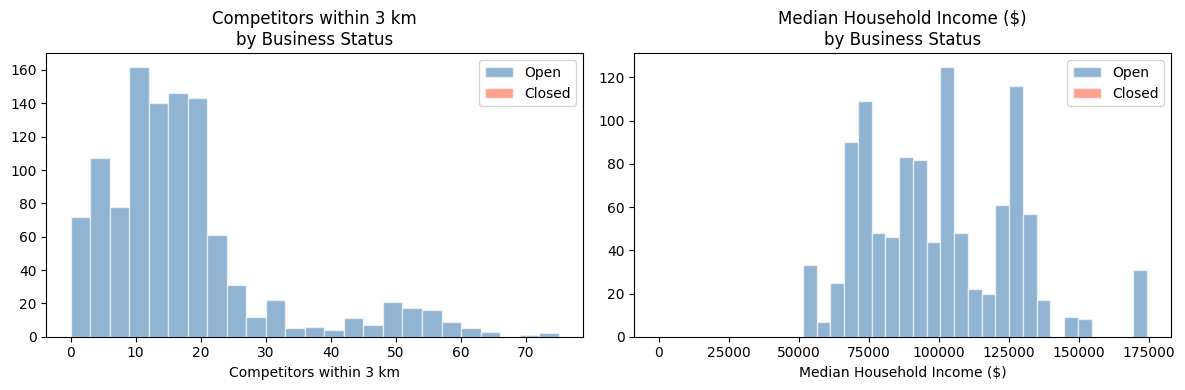

In [5]:
# Competition density vs. closure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(
    axes,
    ['competition_3km', 'median_income'],
    ['Competitors within 3 km', 'Median Household Income ($)']
):
    for val, color, lbl in [(0, 'steelblue', 'Open'), (1, 'tomato', 'Closed')]:
        subset = df[df['is_closed'] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=lbl, edgecolor='white')
    ax.set_xlabel(label)
    ax.set_title(f'{label}\nby Business Status')
    ax.legend()

plt.tight_layout()
plt.savefig('figures/02_competition_income_vs_status.png', dpi=150, bbox_inches='tight')
plt.show()

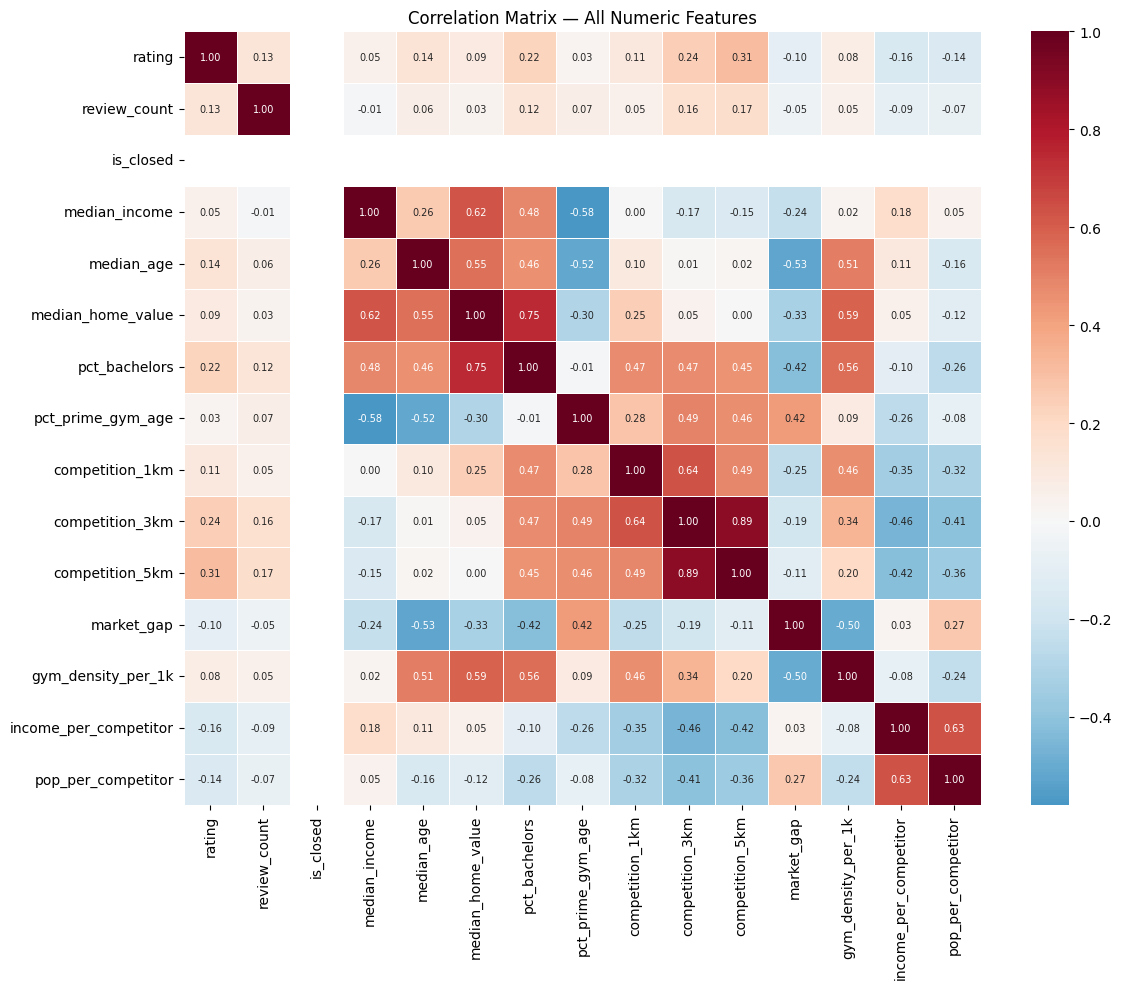

In [6]:
# Correlation matrix of numeric features
numeric_cols = [
    'rating', 'review_count', 'is_closed',
    'median_income', 'median_age', 'median_home_value',
    'pct_bachelors', 'pct_prime_gym_age',
    'competition_1km', 'competition_3km', 'competition_5km',
    'market_gap', 'gym_density_per_1k', 'income_per_competitor',
    'pop_per_competitor',
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — All Numeric Features')
plt.tight_layout()
plt.savefig('figures/02_correlation_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Build Model-Ready Feature Matrices

### Feature set for both tasks:
| Feature | Type | Rationale |
|---|---|---|
| `category_group` | Categorical | Business type |
| `median_income` | Numeric | Neighborhood wealth |
| `median_home_value` | Numeric | Alternate wealth proxy |
| `median_age` | Numeric | Neighborhood age profile |
| `pct_bachelors` | Numeric | Education level |
| `pct_prime_gym_age` | Numeric | % pop 20–44 |
| `total_pop` | Numeric | Market size |
| `competition_1km` | Numeric | Hyper-local competition |
| `competition_3km` | Numeric | Neighborhood competition |
| `market_gap` | Numeric | Opportunity score |
| `gym_density_per_1k` | Numeric | Market saturation |
| `income_per_competitor` | Numeric | Spending power per competitor |
| `price` | Numeric | Price tier (0=unknown, 1–4) |
| `has_hours` | Binary | Business maturity proxy |

> **Note:** `rating` and `review_count` are NOT included as features — they are outputs of success, not inputs to it. We want to predict from *location and market conditions*, not from current performance.

In [7]:
# ── Regressor dataset ──────────────────────────────────────────────────────────
# Open businesses only, with a valid success_score
reg_df = df[(df['is_closed'] == 0)].dropna(subset=['success_score'])
reg_df = reg_df[FEATURES + ['success_score', 'id', 'name', 'zip_code', 'latitude', 'longitude']].copy()
reg_df = reg_df.dropna(subset=FEATURES)

print(f'Regressor dataset: {len(reg_df)} rows')
print('success_score stats:')
print(reg_df['success_score'].describe())

reg_df.to_csv('data/features_regressor.csv', index=False)
print('Saved data/features_regressor.csv')

Regressor dataset: 1080 rows
success_score stats:
count    1080.000000
mean        0.396434
std         0.300914
min         0.000000
25%         0.000000
50%         0.564095
75%         0.628190
max         0.909386
Name: success_score, dtype: float64
Saved data/features_regressor.csv


## 5. Feature Summary

In [8]:
print('=== Classifier Feature Matrix ===')
print(clf_df[FEATURES].describe().T[['mean', 'std', 'min', 'max']].round(2))
print('\n=== Regressor Feature Matrix ===')
print(reg_df[FEATURES].describe().T[['mean', 'std', 'min', 'max']].round(2))

=== Classifier Feature Matrix ===
                            mean        std        min         max
price                       0.03       0.23       0.00        2.00
median_income          100730.98   27465.87   52199.00   174119.00
median_home_value      601599.39  232318.11  243800.00  1795000.00
median_age                 34.17       5.40      23.10       52.80
pct_bachelors              18.82       5.60       6.25       32.78
pct_prime_gym_age          25.48       9.67      11.50       62.86
total_pop               38097.50   17775.56     663.00    88390.00
competition_1km             4.77       4.33       0.00       19.00
competition_3km            21.52      15.27       0.00       62.00
market_gap              58718.08   43090.90    3625.00   280412.50
gym_density_per_1k          0.63       0.60       0.11        4.52
income_per_competitor    8676.71   15392.50     840.51   151343.00

=== Regressor Feature Matrix ===
                            mean        std        min       